In [1]:
import pandas as pd

### plan na ten notebook

* puscic lasso na kazdej kategorii osobno ale tez wspolnie

# Lasso with fixed alpha

In [38]:
# what to leave  -> conclusions from correlation analysis and vibes
# zostaje : node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw

calculated_comp_WS = pd.read_csv('lambdas\calculated_components_WS.csv')
calculated_comp_WS.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_BA = pd.read_csv('lambdas\calculated_components_BA.csv')
calculated_comp_BA.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_ER = pd.read_csv('lambdas\calculated_components_ER.csv')
calculated_comp_ER.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_RGG = pd.read_csv('lambdas\calculated_components_RGG.csv')
calculated_comp_RGG.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_all = pd.read_csv('lambdas\calculated_components_all.csv')
calculated_comp_all.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)


In [39]:
calculated_comp_WS.head()

,score,node_distribution,distance_to_borderlines_raw,edge_length_sum,edge_node_distance_contribution_raw,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry
0,6,23.876561,1368711.422,2.152635,33.782377,0,4.595035,1.818732,0.923854
1,2,125.106129,130.028,2.214927,184.254477,2,4.291184,1.857574,0.994254
2,3,134.195630,23.200,1.848901,206.081081,5,2.975655,2.057628,0.994107
3,4,140.190159,17.622,2.198073,129.139425,4,3.338765,1.824807,0.983865
4,5,53.373121,36.941,3.359785,69.221441,2,4.698183,1.976676,0.983869


In [24]:
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import joblib
# Load your dataset
# 
def Lasso_feature_importance(calculated_components, alpha=.4, save_scaler=False):
    y = calculated_components.iloc[:, 0]
    X = calculated_components.iloc[:, 1:]
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    if save_scaler:
        joblib.dump(scaler, r'scaler/scaler.pkl')

    # Fit the Lasso regression model
    lasso = Lasso(alpha=alpha, random_state=212)
    lasso.fit(X_scaled, y)

    # Get the feature importances
    feature_importances = pd.Series(lasso.coef_, index=X.columns)

    # Display the feature importances
    print("Feature importances using Lasso regression:")
    print(feature_importances)

    feature_importances_df = pd.DataFrame([feature_importances])
    return feature_importances_df
# feature_importances_df.to_csv('feature_importances.csv', index=False)


#

In [42]:
y = calculated_comp_WS.iloc[:, 0]
y

0      6
1      2
2      3
3      4
4      5
      ..
121    1
122    2
123    4
124    5
125    3
Name: score, Length: 126, dtype: int64

In [20]:
import warnings
warnings.filterwarnings("ignore")

fixed_alpha = 0.1

# calculated_comp_WS = pd.read_csv('lambdas\calculated_components_WS.csv')
print(' ====== WS ======')
lasso_ws = Lasso_feature_importance(calculated_comp_WS, fixed_alpha)

# calculated_comp_BA = pd.read_csv('lambdas\calculated_components_BA.csv')
print(' ====== BA ======')
lasso_ba = Lasso_feature_importance(calculated_comp_BA, fixed_alpha)

# calculated_comp_ER = pd.read_csv('lambdas\calculated_components_ER.csv')
print(' ====== ER ======')
lasso_er = Lasso_feature_importance(calculated_comp_ER, fixed_alpha)

# calculated_comp_RGG = pd.read_csv('lambdas\calculated_components_RGG.csv')
print(' ====== RGG ======')
lasso_rgg = Lasso_feature_importance(calculated_comp_RGG, fixed_alpha)

# calculated_comp_all = pd.read_csv('lambdas\calculated_components_all.csv')
print(' ====== ALL ======')
lasso_all = Lasso_feature_importance(calculated_comp_all, fixed_alpha)

 ====== WS ======
Feature importances using Lasso regression:
node_distribution                     -0.464193
distance_to_borderlines_raw            0.037541
edge_length_sum                        0.000000
edge_node_distance_contribution_raw   -0.338640
count_edge_crossings_raw              -0.000000
communities_closeness                  0.162346
sum_of_angles                          0.000000
symmetry                              -0.564405
dtype: float64
 ====== BA ======
Feature importances using Lasso regression:
node_distribution                     -0.485088
distance_to_borderlines_raw            0.401644
edge_length_sum                        0.000000
edge_node_distance_contribution_raw   -0.083192
count_edge_crossings_raw              -0.000000
communities_closeness                  0.127135
sum_of_angles                          0.000000
symmetry                              -0.401795
dtype: float64
 ====== ER ======
Feature importances using Lasso regression:
node_distributio

In [21]:

lasso_ws['category'] = 'WS'
lasso_ba['category'] = 'BA'
lasso_er['category'] = 'ER'
lasso_rgg['category'] = 'RGG'
lasso_all['category'] = 'All'

all_cats_corrs = pd.concat([lasso_ws, lasso_ba, lasso_er, lasso_rgg, lasso_all], ignore_index=True)
all_cats_corrs.set_index('category', inplace=True)

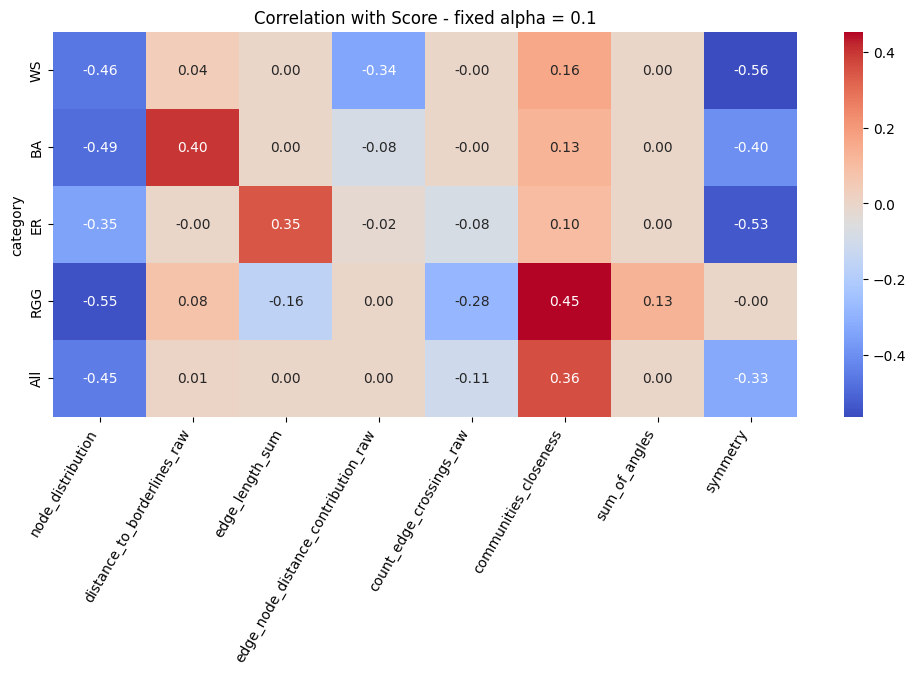

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))  # Adjust the figure size as needed
sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')
plt.title(f'Correlation with Score - fixed alpha = {fixed_alpha}')
plt.show()

In [23]:
lasso_ws.to_csv(r'lambdas/lasso_fixed_alpha_ws.csv', index = False)
lasso_ba.to_csv(r'lambdas/lasso_fixed_alpha_ba.csv', index = False)
lasso_er.to_csv(r'lambdas/lasso_fixed_alpha_er.csv', index = False)
lasso_rgg.to_csv(r'lambdas/lasso_fixed_alpha_rgg.csv', index = False)
lasso_all.to_csv(r'lambdas/lasso_fixed_alpha_all.csv', index = False)

# LASSO with proper training

In [27]:

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

# calculated_components = pd.read_csv('lambdas\\calculated_components_WS.csv')

def Lasso_with_grid_search(calculated_components, category='BA', save_scaler=False):
    y = calculated_components.iloc[:, 0]
    X = calculated_components.iloc[:, 1:]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=212)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    if save_scaler:
        joblib.dump(scaler, fr'scaler/scaler_{category}.pkl')

    # Define the parameter grid for alpha
    param_grid = {'alpha': [i/100 for i in range(1, 100)]}

    # Initialize the Lasso model
    lasso = Lasso(random_state=212)
    grid_search = GridSearchCV(lasso, param_grid, cv=5)
    grid_search.fit(X_train_scaled, y_train)
    best_params = grid_search.best_params_
    print("Best parameters found: ", best_params)

    lasso_best = Lasso(**best_params)
    lasso_best.fit(X_train_scaled, y_train)

    y_pred = lasso_best.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error on test set: ", mse)

    feature_importances = pd.Series(lasso_best.coef_, index=X.columns)
    print("Feature importances using Lasso regression with tuned parameters:")
    print(feature_importances)
    feature_importances_df = pd.DataFrame(feature_importances, columns=['Importance']).T
    return feature_importances_df


In [14]:
# what to leave  -> conclusions from correlation analysis and vibes
# node_distribtuion, distance_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw

calculated_comp_WS = pd.read_csv('lambdas\calculated_components_WS.csv')
calculated_comp_WS.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_BA = pd.read_csv('lambdas\calculated_components_BA.csv')
calculated_comp_BA.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_ER = pd.read_csv('lambdas\calculated_components_ER.csv')
calculated_comp_ER.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_RGG = pd.read_csv('lambdas\calculated_components_RGG.csv')
calculated_comp_RGG.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)

calculated_comp_all = pd.read_csv('lambdas\calculated_components_all.csv')
calculated_comp_all.drop(['node_distribution_raw', 'distance_to_borderlines', 'edge_length_sum_raw', 'edge_node_distance_contribution', 'count_edge_crossings'], axis=1, inplace=True)


In [28]:
print(' ====== WS ======')
features_ws = Lasso_with_grid_search(calculated_comp_WS,'WS', True)
print(' ====== BA ======')
features_ba = Lasso_with_grid_search(calculated_comp_BA, 'BA', True)
print(' ====== ER ======')
features_er = Lasso_with_grid_search(calculated_comp_ER, 'ER', True)
print(' ====== RGG ======')
features_rgg = Lasso_with_grid_search(calculated_comp_RGG, 'RGG', True)
print(' ====== All ======')
features_all = Lasso_with_grid_search(calculated_comp_all, 'All', True)

 ====== WS ======
Best parameters found:  {'alpha': 0.03}
Mean Squared Error on test set:  5.154039178576254
Feature importances using Lasso regression with tuned parameters:
node_distribution                     -0.435429
distance_to_borderlines_raw            0.074066
edge_length_sum                        0.001637
edge_node_distance_contribution_raw   -0.481714
count_edge_crossings_raw              -0.371973
communities_closeness                  0.018568
sum_of_angles                          0.509263
symmetry                              -0.534050
dtype: float64
 ====== BA ======
Best parameters found:  {'alpha': 0.19}
Mean Squared Error on test set:  2.037178420613442
Feature importances using Lasso regression with tuned parameters:
node_distribution                     -0.375911
distance_to_borderlines_raw            0.270080
edge_length_sum                        0.000000
edge_node_distance_contribution_raw   -0.021757
count_edge_crossings_raw              -0.000000
communities

In [29]:

features_ws['category'] = 'WS'
features_ba['category'] = 'BA'
features_er['category'] = 'ER'
features_rgg['category'] = 'RGG'
features_all['category'] = 'All'

all_cats_corrs = pd.concat([features_ws, features_ba, features_er, features_rgg, features_all], ignore_index=True)
all_cats_corrs.set_index('category', inplace=True)

In [30]:

#! saving to file

features_ws.to_csv(r'lambdas\ws_lasso.csv', index=False)
features_er.to_csv(r'lambdas\er_lasso.csv', index=False)
features_ba.to_csv(r'lambdas\ba_lasso.csv', index=False)
features_rgg.to_csv(r'lambdas\rgg_lasso.csv', index=False)
features_all.to_csv(r'lambdas\all_lasso.csv', index=False)

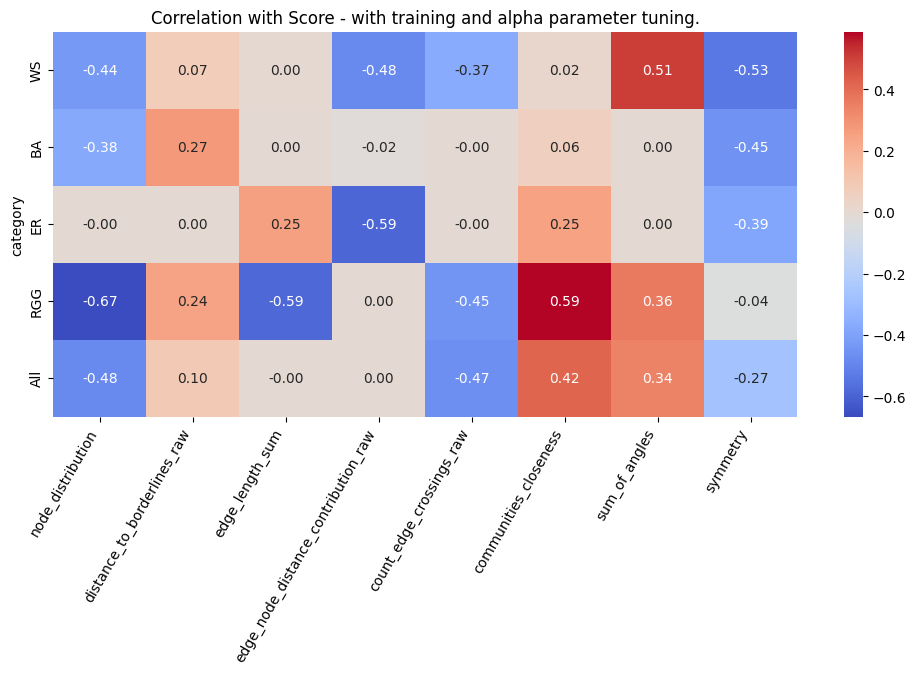

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))  # Adjust the figure size as needed
sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')
plt.title('Correlation with Score - with training and alpha parameter tuning.')
plt.show()

In [ ]:
# node_distribtuion, edge_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw

# Looking into whats going on in scalers

In [32]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_ws.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [2.03069831e+02 1.37480677e+04 4.09256417e+00 7.58018961e+02
 5.09000000e+00 6.26209107e+00 5.56574532e+00 9.74360215e-01]
Variance: [6.00763780e+04 1.85447052e+10 1.21905287e+01 3.99238781e+06
 2.71219000e+01 1.42027299e+01 1.62867739e+01 5.30325486e-04]
Scale: [2.45104831e+02 1.36178945e+05 3.49149377e+00 1.99809605e+03
 5.20786905e+00 3.76865094e+00 4.03568754e+00 2.30287969e-02]


In [33]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_ba.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [625.08709547  67.04643      4.11466006 804.74303453   8.24
   7.77316332   8.97477597   0.97206079]
Variance: [9.49613800e+05 1.97180299e+03 6.46563488e+00 1.98253797e+06
 1.17082400e+02 2.67988669e+01 8.46463320e+01 7.45088386e-04]
Scale: [9.74481298e+02 4.44049884e+01 2.54276127e+00 1.40802627e+03
 1.08204621e+01 5.17676220e+00 9.20034413e+00 2.72963072e-02]


In [34]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_er.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [4.00434499e+02 1.37010397e+03 4.29316339e+00 3.79161377e+02
 5.08000000e+00 5.73322761e+00 5.85601931e+00 9.73115935e-01]
Variance: [6.05977227e+05 1.70120995e+08 1.63958736e+01 2.27964604e+05
 3.39736000e+01 1.35298904e+01 1.85877498e+01 7.56760820e-04]
Scale: [7.78445391e+02 1.30430439e+04 4.04918184e+00 4.77456389e+02
 5.82868767e+00 3.67829994e+00 4.31135127e+00 2.75092861e-02]


In [35]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_rgg.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [2.72391499e+02 2.50216557e+04 4.25367600e+00 1.91483629e+04
 3.73000000e+00 6.20971077e+00 4.57866189e+00 9.58400300e-01]
Variance: [1.30710610e+05 6.06395879e+10 1.59994001e+01 3.50218106e+10
 1.88571000e+01 1.49347671e+01 1.43200666e+01 2.11685563e-03]
Scale: [3.61539223e+02 2.46251067e+05 3.99992501e+00 1.87141151e+05
 4.34247625e+00 3.86455264e+00 3.78418639e+00 4.60092994e-02]


In [36]:
# check whats going on in scaler
scaler = joblib.load(r'scaler/scaler_all.pkl')

print("Mean:", scaler.mean_)
print("Variance:", scaler.var_)
print("Scale:", scaler.scale_)

Mean: [3.28347709e+02 5.72381986e+04 4.37055453e+00 5.33440112e+03
 5.66997519e+00 6.59261712e+00 6.41176897e+00 9.67596939e-01]
Variance: [3.08020865e+05 1.04602848e+12 1.38296668e+01 8.75571219e+09
 5.50250787e+01 1.82524560e+01 4.15660028e+01 1.20018043e-03]
Scale: [5.54996275e+02 1.02275534e+06 3.71882600e+00 9.35719626e+04
 7.41788910e+00 4.27228931e+00 6.44717014e+00 3.46436203e-02]
